In [1]:
# imports
import torch
import shutil
import pickle
import pandas as pd
import numpy as np
from mpmath.libmp import to_int
from torch import nn
from pathlib import Path
from collections import OrderedDict
from kagglehub import dataset_download
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from torch.nn import Sigmoid
from torchvision import transforms, datasets
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader, WeightedRandomSampler, TensorDataset
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog
from IPython.display import display

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
# download dataset

local_data_path = Path("../data")
dataset_base_path = Path(dataset_download("crawford/cat-dataset"))
dataset_base_path = dataset_base_path / "cats"
oreo_path = local_data_path / "oreo"
not_oreo_path = local_data_path / "not_oreo"

oreo_path.mkdir(exist_ok=True)
not_oreo_path.mkdir(exist_ok=True)

for image in local_data_path.glob("*.jpg"):
    shutil.move(str(image), str(oreo_path / image.name))

for subdir in dataset_base_path.iterdir():
    if subdir.is_dir():
        for image in subdir.glob("*.jpg"):
            new_name = f"{subdir.name}_{image.name}"
            shutil.move(str(image), str(not_oreo_path / new_name))

In [3]:
# Split
full_dataset = datasets.ImageFolder(local_data_path)

x_data = []
y_data = []

for image, label in full_dataset:
    x_data.append(image)
    y_data.append(label)

# 80% Train
x_train, x_test, y_train, y_test = train_test_split(
    x_data,
    y_data,
    test_size=0.2,
    stratify=y_data,
    random_state=42
)

# 10% validation
# 10% test
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

In [3]:
# Split (faster)

# Apply a basic transform here so we get tensors, not PIL Images
base_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(local_data_path, transform=base_transform)

# Use DataLoader with num_workers for parallel I/O
loader = DataLoader(full_dataset, batch_size=64, shuffle=False, num_workers=4)

x_data_batches = []
y_data_batches = []

for images, labels in loader:
    x_data_batches.append(images)
    y_data_batches.append(labels)

x_data = torch.cat(x_data_batches)       # shape: (N, C, H, W)
y_data = torch.cat(y_data_batches).tolist()

# 80% Train
indices = list(range(len(x_data)))
x_train_idx, x_test_idx, y_train, y_test = train_test_split(
    indices, y_data, test_size=0.2, stratify=y_data, random_state=42
)
x_train = x_data[x_train_idx]
x_test  = x_data[x_test_idx]

# 10% validation / 10% test
train_indices = list(range(len(x_train)))
x_train_idx2, x_val_idx, y_train, y_val = train_test_split(
    train_indices, y_train, test_size=0.2, stratify=y_train, random_state=42
)
x_val   = x_train[x_val_idx]
x_train = x_train[x_train_idx2]

In [4]:
# preprocessing

x_train_proc = x_train.to(device)
x_val_proc = x_val.to(device)
x_test_proc = x_test.to(device)

# Resize, Augment, and Normalize RGB
cnn_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2), # random brightness
])

cnn_x_train_proc = torch.stack([cnn_transform(img) for img in x_train]).to(device)

In [5]:
# Weighted Random Sampler

class_sample_count = np.array([len(np.where(y_train == t)[0]) for t in np.unique(y_train)])
weight = 1. / class_sample_count
samples_weight = np.array([weight[t] for t in y_train])
samples_weight = torch.from_numpy(samples_weight)

sampler = WeightedRandomSampler(
   weights=samples_weight,
    num_samples=len(samples_weight),
    replacement=True
)

#train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=4)
cnn_y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
data = TensorDataset(cnn_x_train_proc, cnn_y_train)
cnn_train_loader = DataLoader(data, batch_size=32, sampler=sampler, num_workers=0)
#val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
#test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

#images, labels = next(iter(train_loader))

In [6]:
# train
x_train_hog = []

for image in x_train_proc:
    img_np = image.cpu().permute(1, 2, 0).numpy()
    feat = hog(
        img_np,
        orientations=6,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        channel_axis=-1
    )
    x_train_hog.append(feat)

# validation
x_val_hog = []

for image in x_val_proc:
    img_np = image.cpu().permute(1, 2, 0).numpy()
    feat = hog(
        img_np,
        orientations=6,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        channel_axis=-1
    )
    x_val_hog.append(feat)

# test
x_test_hog = []

for image in x_test_proc:
    img_np = image.cpu().permute(1, 2, 0).numpy()
    feat = hog(
        img_np,
        orientations=6,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        channel_axis=-1
    )
    x_test_hog.append(feat)

In [7]:
#PCA on the images
pca = PCA(n_components=0.95)
x_train = pca.fit_transform(x_train_hog)
x_val_new = pca.transform(x_val_hog)
x_test_new = pca.transform(x_test_hog)

In [8]:
# standard scaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val_new = scaler.transform(x_val_new)
x_test_new = scaler.transform(x_test_new)

In [10]:
# hyperparameter tuning
C_values = [20, 10, 5, 1, 0.5, 0.1, 0.05]
iterations = [15000, 10000, 5000, 1000]
log_reg_model = None
best_f1 = 0
best_C = None
f1_scores = []
val_accuracy = []
C_value = 0.05
iteration = 15000

#log_f1_score = pd.DataFrame(index=iterations)

# f1 validation
#for C in C_values:
    #print(C)
    #for iteration in iterations:
        #print(iteration)
        #regression = LogisticRegression(max_iter=iteration, solver='saga', C=C, class_weight='balanced')

        #regression.fit(x_train, y_train)
        #val_preds = regression.predict(x_val_new)

        #f1 = f1_score(y_val, val_preds, average='macro')
        #f1_scores.append(f1)
        #accuracy = accuracy_score(y_val, val_preds)
        #val_accuracy.append(accuracy)

        #if f1 > best_f1:
            #best_f1 = f1
            #log_reg_model = regression
            #best_C = C

        #log_f1_score.at[iteration, C] = f1
#display(log_f1_score)

# Log Reg after validation
log_reg_model = LogisticRegression(max_iter=iteration, solver='saga', C=C_value, class_weight='balanced')
log_reg_model.fit(x_train, y_train)

C:\Users\tdows\Desktop\Machine Learning\Machine_Learning_OreoFinder\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.05
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :te

In [11]:
# K-NN

# Validation
k_val = [1, 2, 3, 5, 7, 9]
best_k = 1
best_f1 = 0
f1_scores = []

knn_f1_scores = pd.DataFrame(index=k_val)

# KNN validation
for k in k_val:
    model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    model.fit(x_train, y_train)
    val_predictions = model.predict(x_val_new)
    f1 = f1_score(y_val, val_predictions, average='macro')
    f1_scores.append(f1)
    print(f"k={k}, Validation F1 Score: {f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_k = k

    knn_f1_scores.at[k, "f1 score"] = f1

display(knn_f1_scores)

# KNN training
knn_model = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_model.fit(x_train, y_train)

k=1, Validation F1 Score: 0.7977
k=2, Validation F1 Score: 0.7247
k=3, Validation F1 Score: 0.7247
k=5, Validation F1 Score: 0.6442
k=7, Validation F1 Score: 0.5660
k=9, Validation F1 Score: 0.5594


,f1 score
1,0.797742
2,0.724694
3,0.724694
5,0.644225
7,0.565989
9,0.559392


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [12]:
# CNN
learning_rates = [1, 0.1, 0.01, 0.001, 0.0001, 0.00001]
best_learning_rate = 0.0001
bars = [0.1, 0.3, 0.5, 0.7, 0.9, 0.99]
best_bar = 0.7
epochs = 2000
current_f1 = 0
best_f1 = 0

f1_cnn_score = pd.DataFrame(index=learning_rates)

for learning_rate in learning_rates:
    print(learning_rate)
    for bar in bars:
        print(bar)
        cnn_model = nn.Sequential(
            OrderedDict([
                ("conv1", nn.Conv2d(3, 128, kernel_size=3, padding=1)),
                ("norm1", nn.BatchNorm2d(128)),
                ("relu1", nn.LeakyReLU(0.01)),
                ("pool1", nn.MaxPool2d(kernel_size=2, stride=2)),
                ("conv2", nn.Conv2d(128, 64, kernel_size=3, padding=1)),
                ("norm2", nn.BatchNorm2d(64)),
                ("relu2", nn.LeakyReLU(0.01)),
                ("pool2", nn.MaxPool2d(kernel_size=2, stride=2)),
                ("conv3", nn.Conv2d(64, 32, kernel_size=3, padding=1)),
                ("norm3", nn.BatchNorm2d(32)),
                ("relu3", nn.LeakyReLU(0.01)),
                ("pool3", nn.MaxPool2d(kernel_size=2, stride=2)),
                ("dropout", nn.Dropout2d(0.5)),
                ("flatten", nn.Flatten()),
                ("linear1", nn.Linear(32 * 16 * 16, 128)),
                ("relu5", nn.ReLU()),
                ("linear2", nn.Linear(in_features=128, out_features=1)),
            ])
        ).to(device)

        criterion = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.Adam(cnn_model.parameters(), lr=learning_rate)

        best_f1_val = 0
        num_worse = 0
        leniency = 5
        best_cnn_model_val = None

        for epoch in range(epochs):
            cnn_model.train()
            total_loss = 0
            for images, labels in cnn_train_loader:
                optimizer.zero_grad()
                outputs = cnn_model(images).squeeze(1)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            predictions = []

            cnn_model.eval()
            with torch.no_grad():
                probabilities = torch.sigmoid(cnn_model(x_val_proc))
                predictions = (probabilities > bar).int()

            f1 = f1_score(y_val, predictions.cpu(), average='macro')

            if f1 > best_f1_val:
                best_cnn_model_val = cnn_model
                best_f1_val = f1
                num_worse = 0
            else:
                num_worse += 1

            if num_worse >= leniency:
                break

        if f1 > best_f1:
            best_cnn_model = best_cnn_model_val

        f1_cnn_score.at[learning_rate, bar] = best_f1_val

display(f1_cnn_score)



#train_losses = []
#val_f1s = []
#x_val_tensor = x_val.to(device)
#y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)

#for epoch in range(epochs):
    #cnn_model.train()
    #total_loss = 0
    #for images, labels in cnn_train_loader:
        #optimizer.zero_grad()
        #outputs = cnn_model(images).squeeze(1)
        #loss = criterion(outputs, labels)
        #loss.backward()
        #optimizer.step()
        #total_loss += loss.item()
    #train_losses.append(total_loss)

    #val_proba = predict_in_batches(cnn_model, x_val)
    #val_preds = (val_proba > 0.5).astype(int)
    #epoch_f1  = f1_score(y_val, val_preds, average='macro')
    #val_f1s.append(epoch_f1)

    #print(f"Epoch {epoch+1}/{epochs}  loss={total_loss:.4f}  val_f1={epoch_f1:.4f}")

1
0.1
0.3
0.5
0.7
0.9
0.99
0.1
0.1
0.3
0.5
0.7
0.9
0.99
0.01
0.1
0.3
0.5
0.7
0.9
0.99
0.001
0.1
0.3
0.5
0.7
0.9
0.99
0.0001
0.1
0.3
0.5
0.7
0.9
0.99
1e-05
0.1
0.3
0.5
0.7
0.9
0.99


,0.10,0.30,0.50,0.70,0.90,0.99
1.00000,0.070354,0.070354,0.480336,0.480336,0.480336,0.480336
0.10000,0.070354,0.075633,0.557046,0.480336,0.501260,0.480336
0.01000,0.849437,0.884772,0.871912,0.893188,0.869698,0.889028
0.00100,0.889470,0.846771,0.909923,0.922396,0.923339,0.903000
0.00010,0.878119,0.915643,0.909310,0.928980,0.916848,0.850577
0.00001,0.818433,0.803506,0.846749,0.890487,0.919347,0.890995


In [13]:
# Save the models
log_reg_path = Path("..") / "models" / "logRegModel.pkl"
with open(log_reg_path, 'wb') as f:
    pickle.dump(log_reg_model, f)

knn_path = Path("..") / "models" / "knnModel.pkl"
with open(knn_path, 'wb') as f:
    pickle.dump(knn_model, f)

cnn_path = Path("..") / "models" / "cnnModel.pkl"
with open(cnn_path, 'wb') as f:
    pickle.dump(best_cnn_model, f)

In [9]:
# Load the models

log_reg_path = Path("..") / "models" / "logRegModel.pkl"
with open(log_reg_path, 'rb') as f:
    log_reg_model = pickle.load(f)

knn_path = Path("..") / "models" / "knnModel.pkl"
with open(knn_path, 'rb') as f:
    knn_model = pickle.load(f)

cnn_path = Path("..") / "models" / "cnnModel.pkl"
with open(cnn_path, 'rb') as f:
    cnn_model = pickle.load(f)

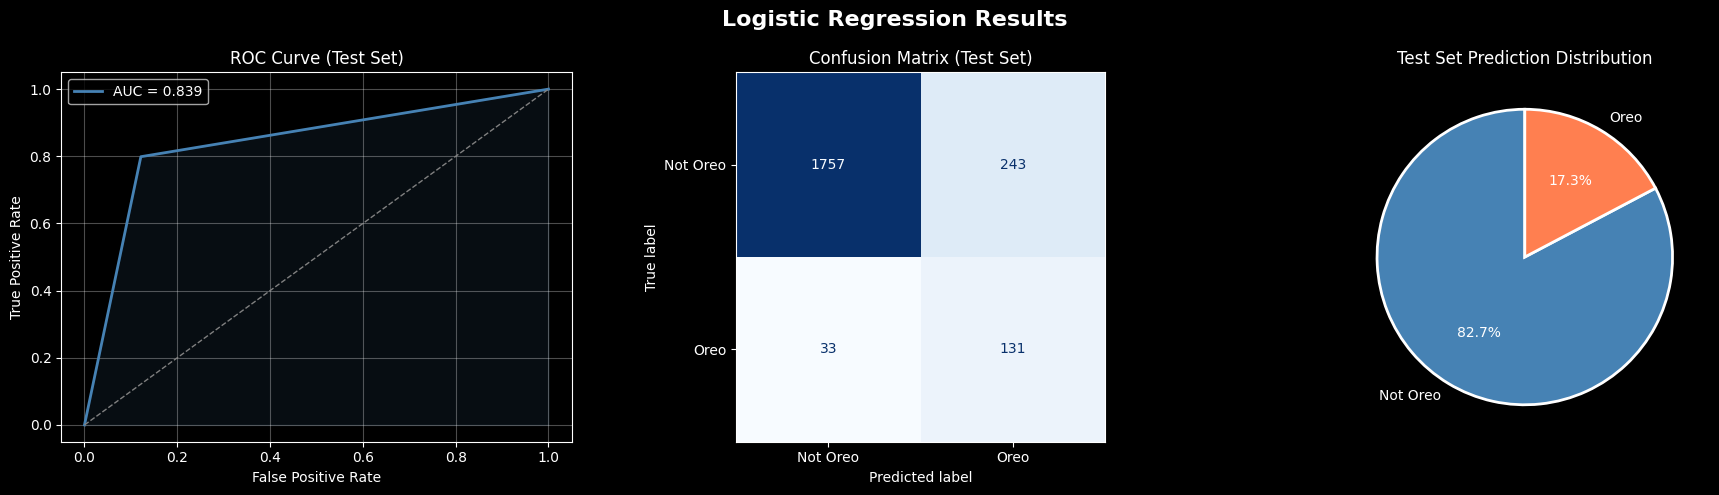

In [11]:
# Logistic Regression Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Logistic Regression Results", fontsize=16, fontweight='bold')

predictions = log_reg_model.predict(x_test_new)

# 1. ROC-AUC
fpr, tpr, _ = roc_curve(y_test, predictions)
auc = roc_auc_score(y_test, predictions)
ax3 = axes[0]
ax3.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {auc:.3f}')
ax3.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)
ax3.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax3.set_xlabel("False Positive Rate")
ax3.set_ylabel("True Positive Rate")
ax3.set_title("ROC Curve (Test Set)")
ax3.legend()
ax3.grid(True, alpha=0.3)

# 2. Confusion matrix
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Oreo', 'Oreo'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title("Confusion Matrix (Test Set)")

# 3. Prediction distribution
oreo_count     = sum(predictions)
not_oreo_count = len(predictions) - oreo_count
axes[2].pie(
    [not_oreo_count, oreo_count],
    labels=['Not Oreo', 'Oreo'],
    autopct='%1.1f%%',
    colors=['steelblue', 'coral'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[2].set_title("Test Set Prediction Distribution")

plt.tight_layout()
plt.savefig("logistic_regression_results.png", dpi=150, bbox_inches='tight')
plt.show()

Test Accuracy: 0.9598


NameError: name 'k_val' is not defined

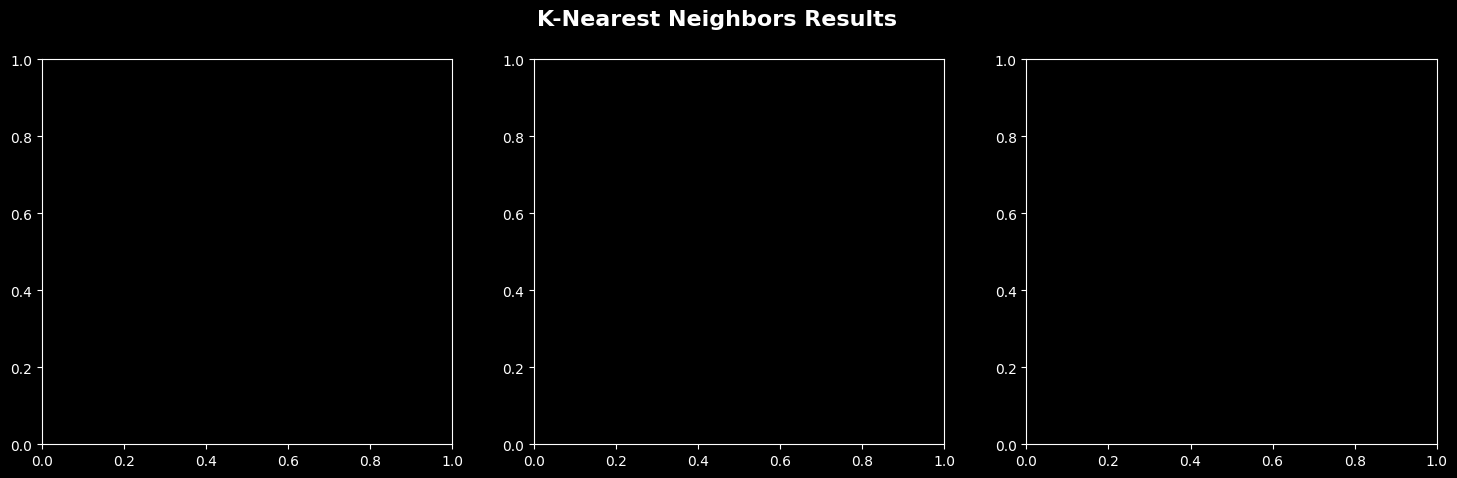

In [12]:
predictions = knn_model.predict(x_test_new)
accuracy = np.mean(predictions == y_test)
print(f"Test Accuracy: {accuracy:.4f}")

# ── Graphs ──────────────────────────────────────────────────────────────────

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("K-Nearest Neighbors Results", fontsize=16, fontweight='bold')

# 1. F1 score vs k
ax1 = axes[0]
ax1.plot(k_val, f1_scores, marker='o', color='steelblue', linewidth=2, markersize=7)
ax1.axvline(x=best_k, color='coral', linestyle='--', linewidth=1.5, label=f'Best k={best_k}')
ax1.scatter([best_k], [best_f1], color='coral', zorder=5, s=100)
for k, f1 in zip(k_val, f1_scores):
    ax1.annotate(f'{f1:.3f}', (k, f1), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=8)
ax1.set_xlabel("k")
ax1.set_ylabel("Macro F1 Score")
ax1.set_title("Validation F1 Score by k")
ax1.set_xticks(k_val)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Confusion matrix
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Oreo', 'Oreo'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title("Confusion Matrix (Test Set)")

# 3. ROC curve
pred_proba = knn_model.predict_proba(x_test_new)[:, 1]
fpr, tpr, _ = roc_curve(y_test, pred_proba)
auc = roc_auc_score(y_test, pred_proba)
ax3 = axes[2]
ax3.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {auc:.3f}')
ax3.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)
ax3.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax3.set_xlabel("False Positive Rate")
ax3.set_ylabel("True Positive Rate")
ax3.set_title("ROC Curve (Test Set)")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("knn_results.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Incorrect predictions with neighbors ────────────────────────────────────
# incorrect = np.where(((predictions == 1) & (np.array(y_test) == 0)) |
#                      ((predictions == 0) & (np.array(y_test) == 1)))[0]
# num_mistakes = len(incorrect)

# if num_mistakes > 0:
#     fig, axes = plt.subplots(num_mistakes, best_k + 1, figsize=(20, 4 * num_mistakes))
#     if num_mistakes == 1:
#         axes = np.expand_dims(axes, axis=0)

#     for i, test_idx in enumerate(incorrect):
#         sample = x_test_new[test_idx]
#         distances, neighbor_indices = knn_model.kneighbors(sample.reshape(1, -1), n_neighbors=best_k)

#         ax_test = axes[i, 0]
#         img = original_test_images[test_idx].permute(1, 2, 0).numpy()
#         ax_test.imshow(np.clip(img, 0, 1))
#         true_label = 'Oreo' if y_test[test_idx] == 1 else 'Not Oreo'
#         pred_label = 'Oreo' if predictions[test_idx] == 1 else 'Not Oreo'
#         ax_test.set_title(f"True: {true_label}\nPred: {pred_label}", color='red')
#         ax_test.axis('off')

#         for j, train_idx in enumerate(neighbor_indices[0]):
#             ax_nb = axes[i, j + 1]
#             neighbor_img = original_train_images[train_idx].permute(1, 2, 0).numpy()
#             ax_nb.imshow(np.clip(neighbor_img, 0, 1))
#             nb_label = 'Oreo' if y_train[train_idx] == 1 else 'Not Oreo'
#             ax_nb.set_title(f"Neighbor {j+1} ({nb_label})\nDist: {distances[0][j]:.2f}", fontsize=8)
#             ax_nb.axis('off')

#     fig.suptitle("Incorrect Predictions & Their Nearest Neighbors", fontsize=14, fontweight='bold')
#     plt.tight_layout()
#     plt.savefig("knn_mistakes.png", dpi=150, bbox_inches='tight')
#     plt.show()

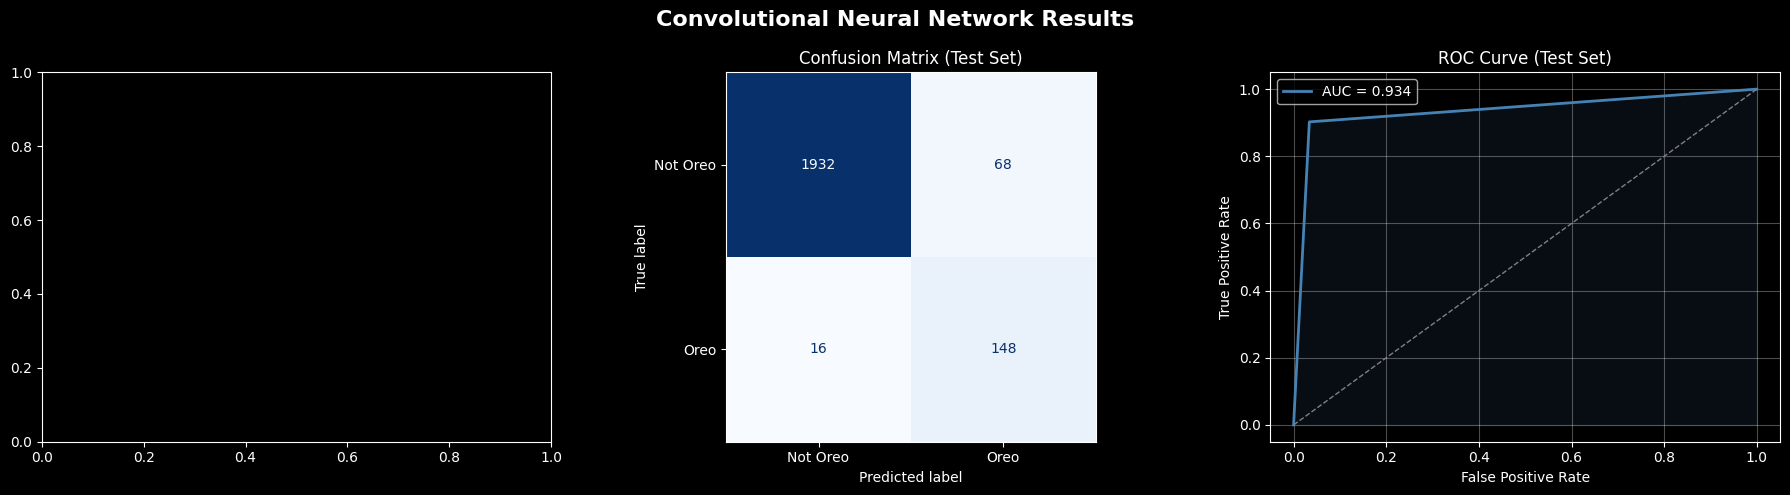

In [10]:
# ── Test predictions ─────────────────────────────────────────────────────────
predictions = []

cnn_model.eval()
with torch.no_grad():
    probabilities = torch.sigmoid(cnn_model(x_test_proc))
    predictions = (probabilities > 0.7).squeeze().cpu().int().numpy()

# ── Graphs ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Convolutional Neural Network Results", fontsize=16, fontweight='bold')

# 1. Training loss + validation F1 over epochs
#ax1 = axes[0]
#color_loss = 'steelblue'
#color_f1   = 'coral'
#ep = range(1, epochs + 1)
#ax1.plot(ep, train_losses, color=color_loss, linewidth=2, label='Train Loss')
#ax1.set_xlabel("Epoch")
#ax1.set_ylabel("Loss", color=color_loss)
#ax1.tick_params(axis='y', labelcolor=color_loss)
#ax1.set_title("Loss & Validation F1 over Epochs")
#ax2 = ax1.twinx()
#ax2.plot(ep, val_f1s, color=color_f1, linewidth=2, linestyle='--', label='Val F1')
#ax2.set_ylabel("Macro F1", color=color_f1)
#ax2.tick_params(axis='y', labelcolor=color_f1)
#lines1, labels1 = ax1.get_legend_handles_labels()
#lines2, labels2 = ax2.get_legend_handles_labels()
#ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
#ax1.grid(True, alpha=0.3)

# 2. Confusion matrix
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Oreo', 'Oreo'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title("Confusion Matrix (Test Set)")

# 3. ROC curve
fpr, tpr, _ = roc_curve(y_test, predictions)
auc = roc_auc_score(y_test, predictions)
ax3 = axes[2]
ax3.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {auc:.3f}')
ax3.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)
ax3.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax3.set_xlabel("False Positive Rate")
ax3.set_ylabel("True Positive Rate")
ax3.set_title("ROC Curve (Test Set)")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cnn_results.png", dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# evaluation

models = pd.DataFrame(index=["Accuracy", "Precision", "Recall", "F1", "AUC"])

lr_accuracy = accuracy_score(y_test, log_reg_model.predict(x_test_new))
lr_precision = precision_score(y_test, log_reg_model.predict(x_test_new))
lr_recall = recall_score(y_test, log_reg_model.predict(x_test_new))
lr_f1 = f1_score(y_test, log_reg_model.predict(x_test_new))
lr_auc = roc_auc_score(y_test, log_reg_model.predict(x_test_new))
lr_roc = roc_curve(y_test, log_reg_model.predict(x_test_new))

models["Logistic Regression"] = [lr_accuracy, lr_precision, lr_recall, lr_f1, lr_auc]

knn_accuracy = accuracy_score(y_test, knn_model.predict(x_test_new))
knn_precision = precision_score(y_test, knn_model.predict(x_test_new))
knn_recall = recall_score(y_test, knn_model.predict(x_test_new))
knn_f1 = f1_score(y_test, knn_model.predict(x_test_new))
knn_auc = roc_auc_score(y_test, knn_model.predict(x_test_new))
knn_roc = roc_curve(y_test, knn_model.predict(x_test_new))

models["K-Nearest Neighbor"] = [knn_accuracy, knn_precision, knn_recall, knn_f1, knn_auc]

predictions = []

cnn_model.eval()
with torch.no_grad():
    probabilities = torch.sigmoid(cnn_model(x_test_proc))
    predictions = (probabilities > 0.7).squeeze().cpu().int().numpy()

cnn_accuracy = accuracy_score(y_test, predictions)
cnn_precision = precision_score(y_test, predictions)
cnn_recall = recall_score(y_test, predictions)
cnn_f1 = f1_score(y_test, predictions)
cnn_auc = roc_auc_score(y_test, predictions)
cnn_roc = roc_curve(y_test, predictions)

models["Convolutional Neural Network"] = [cnn_accuracy, cnn_precision, cnn_recall, cnn_f1, cnn_auc]

display(models)

,Logistic Regression,K-Nearest Neighbor,Convolutional Neural Network
Accuracy,0.872458,0.959797,0.961183
Precision,0.350267,0.987342,0.685185
Recall,0.798780,0.475610,0.902439
F1,0.486989,0.641975,0.778947
AUC,0.838640,0.737555,0.934220
